In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# --- Funções de Processamento de Dados (Mantidas) ---

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of dictionaries, each containing (f, t, Zxx) for an epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            # print(f"        Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Ensure epoch is long enough for the STFT window
        if len(epoch) < nperseg:
            # print(f"        Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# --- Configurações Globais ---

# Pasta raiz contendo todas as subpastas de sujeitos (S001, S002, ...)
# Exemplo: Se seus arquivos estão em 'seu_projeto/data/phisionet_data/S001/'
# E o script está em 'seu_projeto/'
pasta_raiz_sujeitos = Path('data/phisionet_data') # <-- AJUSTE ISSO PARA O SEU CAMINHO RAIZ DOS SUJEITOS

# Define o range de sujeitos S001 a S109
# Ajuste 'start_subject' e 'end_subject' conforme sua necessidade (ex: de S001 a S030)
start_subject = 1
end_subject = 50 # Ou 30, ou qualquer outro número até 109

registros = ['R04', 'R08', 'R12'] # Arquivos EDF a serem processados por sujeito
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Mapeamento para nomes de pastas em minúsculas
epoch_duration_sec = 4 # Duração de cada época em segundos (tmax - tmin)

# Definir a taxa de amostragem globalmente (ASSUMIR UM VALOR CONSISTENTE OU LER DO PRIMEIRO ARQUIVO)
fs = 160 # Hz - Ajuste para a taxa de amostragem real dos seus dados

# Definir as durações de janela da STFT a serem testadas (em milissegundos)
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]

print(f"Iniciando a geração de spectrograms para sujeitos S{start_subject:03d} a S{end_subject:03d}")
print(f"e para as janelas: {window_durations_ms}ms")

# --- Loop Principal para Processamento (Aninhado) ---

# Loop externo: sobre cada duração de janela da STFT
for current_window_ms in window_durations_ms:
    current_window_s = current_window_ms / 1000.0
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * current_window_s)
    noverlap = int(nperseg * 0.75) # 75% de sobreposição para boa resolução temporal
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1 e noverlap < nperseg
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)
    if nperseg == 1:
        noverlap = 0

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    # Diretório de saída final para o dataset unificado para esta janela específica
    base_output_data_dir = f"unified_spectrograms_{current_window_ms}ms"
    
    # Crie as pastas de classe dentro do diretório de saída para esta janela
    for class_folder_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, class_folder_name), exist_ok=True)
    print(f"Diretório de saída para o dataset unificado: {base_output_data_dir}")

    # Loop intermediário: sobre cada sujeito no range especificado
    for subject_num in range(start_subject, end_subject + 1):
        subject_id = f'S{subject_num:03d}' # Formata para S001, S002, etc.
        subject_folder_path = pasta_raiz_sujeitos / subject_id

        if not subject_folder_path.is_dir():
            print(f"  Pasta do sujeito {subject_id} não encontrada em {pasta_raiz_sujeitos}. Pulando.")
            continue

        print(f"  Processando Sujeito: {subject_id}")

        # Loop interno: sobre cada arquivo EDF (R04, R08, R12) dentro do sujeito
        for registro in registros:
            # Encontrar arquivo .edf correspondente
            edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
            if not edf_file:
                print(f"    Arquivo {registro}.edf não encontrado em {subject_folder_path}. Pulando.")
                continue

            # print(f"      Processando arquivo: {edf_file.name}") # Descomente para mais detalhes
            
            # Carregar dados EDF usando EdfReader
            reader = EdfReader(str(edf_file))
            
            # Obter informações dos sinais e taxa de amostragem (use a global 'fs' ou leia por arquivo)
            # Se sua taxa de amostragem varia por arquivo, DESCOMENTE A LINHA ABAIXO
            # fs_current_file = reader.getSampleFrequency(0)
            # E substitua 'fs' por 'fs_current_file' nas chamadas de função e nos cálculos nperseg/noverlap
            
            n_channels = reader.signals_in_file
            signal_labels = reader.getSignalLabels()
            signals_data = np.array([reader.readSignal(c) for c in range(n_channels)])
            
            # Obter canais C3 e C4
            try:
                c3_idx = signal_labels.index('C3..')
                c4_idx = signal_labels.index('C4..')
            except ValueError:
                print(f"        Canais 'C3..' ou 'C4..' não encontrados em {edf_file.name}. Pulando este arquivo.")
                reader.close()
                continue

            c3_signal = signals_data[c3_idx, :]
            c4_signal = signals_data[c4_idx, :]
            
            # Ler anotações diretamente do arquivo EDF
            annotations_onset, annotations_duration, annotations_description = reader.readAnnotations()
            reader.close() # Fechar o reader após ler tudo

            # Converter anotações para formato de eventos (amostras em vez de segundos)
            events = []
            for onset, duration, description in zip(annotations_onset, annotations_duration, annotations_description):
                events.append([int(onset * fs), 0, description])
            
            # Aplicar filtros
            c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
            c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
            
            # Processar condições (T0, T1, T2)
            conditions = ['T0', 'T1', 'T2']
            all_epoch_stfts_for_file = {} # Armazena STFTs para o arquivo atual

            for cond_key in conditions:
                # print(f"        Calculando STFT para {event_dict[cond_key].capitalize()}...")
                c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                
                all_epoch_stfts_for_file[cond_key] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

            # Saving Spectrograms to the unified structure
            for cond_key in conditions:
                c3_data = all_epoch_stfts_for_file[cond_key]['C3']
                c4_data = all_epoch_stfts_for_file[cond_key]['C4']

                # Diretório de saída específico para esta classe (ex: 'unified_spectrograms_200ms/rest')
                class_output_dir = os.path.join(base_output_data_dir, event_dict[cond_key])
                # print(f"        Salvando espectrogramas em: {class_output_dir}") # Descomente para mais detalhes

                # Iterar sobre cada época individual para salvar
                for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
                    epoch_idx = c3_data[j]['epoch_idx']
                    f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
                    f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']

                    # Nome do arquivo agora inclui Sujeito_Registro_Época_Canal
                    base_filename = f"{subject_id}_{edf_file.stem.replace('.', '_')}_epoch_{epoch_idx+1}" # Ex: S001_R04_epoch_1

                    # Caminho completo para salvar o arquivo .npy C3
                    npy_c3_path = os.path.join(class_output_dir, f"{base_filename}_C3.npy")
                    np.save(npy_c3_path, Zxx_c3)

                    # Caminho completo para salvar o arquivo .npy C4
                    npy_c4_path = os.path.join(class_output_dir, f"{base_filename}_C4.npy")
                    np.save(npy_c4_path, Zxx_c4)

                    # (Opcional: Manter o salvamento do PNG se desejar visualizar os espectrogramas)
                    # Recomendo FORTEMENTE DESABILITAR para grandes datasets, pois consome MUITO espaço e tempo.
                    # Se for manter, adapte o nome do arquivo para incluir subject_id e edf_file.stem
                    # assim como os .npy para evitar sobrescrever.
                    # fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
                    # im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
                    # fig.colorbar(im1, ax=axes[0], label='Magnitude')
                    # axes[0].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C3')
                    # axes[0].set_ylabel('Frequência [Hz]')
                    # axes[0].set_xlabel('Tempo [s]')
                    # axes[0].set_ylim([8, 30])
                    # im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
                    # fig.colorbar(im2, ax=axes[1], label='Magnitude')
                    # axes[1].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C4')
                    # axes[1].set_xlabel('Tempo [s]')
                    # axes[1].set_ylim([8, 30])
                    # plt.tight_layout()
                    # png_path = os.path.join(class_output_dir, f"{base_filename}.png")
                    # plt.savefig(png_path)
                    # plt.close(fig)

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos na estrutura unificada em seus respectivos diretórios de janela.")

Iniciando a geração de spectrograms para sujeitos S001 a S050
e para as janelas: [50, 100, 200, 400, 600, 800, 1000]ms

--- Processando com Janela de 50ms (nperseg=8, noverlap=6) ---
Diretório de saída para o dataset unificado: unified_spectrograms_50ms
  Processando Sujeito: S001
  Processando Sujeito: S002
  Processando Sujeito: S003
  Processando Sujeito: S004
  Processando Sujeito: S005
  Processando Sujeito: S006
  Processando Sujeito: S007
  Processando Sujeito: S008
  Processando Sujeito: S009
  Processando Sujeito: S010
  Processando Sujeito: S011
  Processando Sujeito: S012
  Processando Sujeito: S013
  Processando Sujeito: S014
  Processando Sujeito: S015
  Processando Sujeito: S016
  Processando Sujeito: S017
  Processando Sujeito: S018
  Processando Sujeito: S019
  Processando Sujeito: S020
  Processando Sujeito: S021
  Processando Sujeito: S022
  Processando Sujeito: S023
  Processando Sujeito: S024
  Processando Sujeito: S025
  Processando Sujeito: S026
  Processando Suje

In [3]:
sample_spectrogram = np.load('unified_spectrograms_200ms\left\S001_S001R04_epoch_1_C3.npy')
print(sample_spectrogram.shape) # Isso te dará (altura, largura)

(33, 81)


Assumindo IMG_HEIGHT=33 e IMG_WIDTH=81. Verifique se isso está correto.

--- Treinando o modelo para dados numéricos em unified_spectrograms_200ms ---
Tentando ler do diretório raiz: unified_spectrograms_200ms
  Verificando diretório da classe: unified_spectrograms_200ms\rest
  Verificando diretório da classe: unified_spectrograms_200ms\left
  Verificando diretório da classe: unified_spectrograms_200ms\right
Total de arquivos C3 encontrados: 4500
Total de arquivos C4 encontrados: 4500
Total de rótulos encontrados: 4500


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 79, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,619 (1.36 MB)

 Trainable params: 355,619 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4817 - loss: 1.0619 - val_accuracy: 0.5022 - val_loss: 1.0457
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5116 - loss: 1.0171 - val_accuracy: 0.4844 - val_loss: 1.0154
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5031 - loss: 1.0117 - val_accuracy: 0.5144 - val_loss: 0.9692
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5031 - loss: 1.0010 - val_accuracy: 0.5078 - val_loss: 0.9596
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5169 - loss: 0.9815 - val_accuracy: 0.5244 - val_loss: 0.9696
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5189 - loss: 0.9819 - val_accuracy: 0.5267 - val_loss: 0.9562
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5309 - loss: 0.9570 - val_accuracy: 0.5567 - val_loss: 0.9421
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5096 - loss: 0.9755 - 

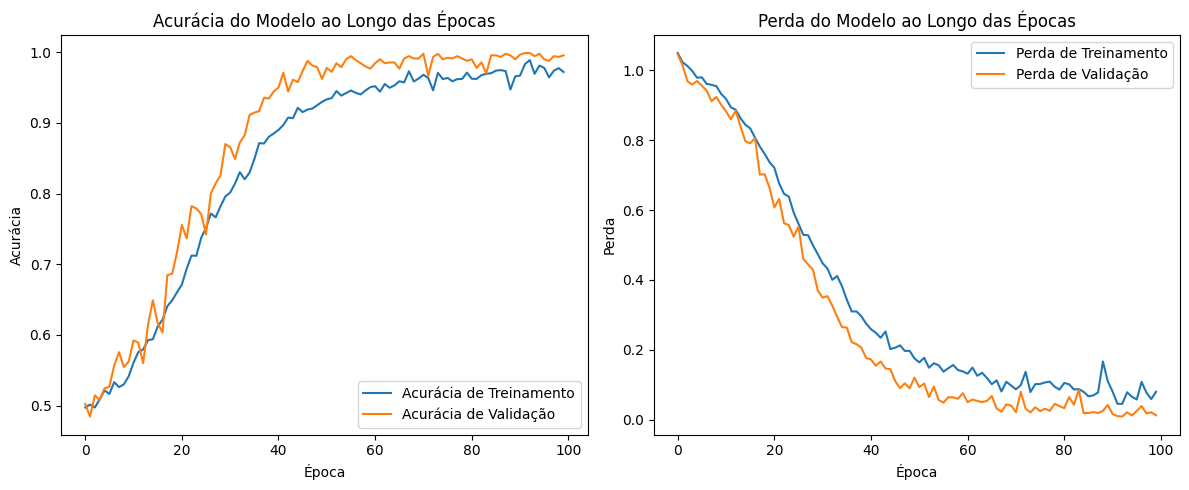

Modelo salvo como 'eeg_spectrogram_cnn_model_npy_200ms.keras'


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt # Importar matplotlib para as plotagens

# --- Parâmetros de Configuração ---
# ESTAS DIMENSÕES SÃO CRUCIAIS!
# Certifique-se de que correspondem EXATAMENTE à saída da sua STFT.
# Para verificar, carregue um dos seus arquivos .npy gerados e imprima o shape:
# import numpy as np
# sample_spec = np.load('unified_spectrograms_200ms/rest/S001_R04_epoch_1_C3.npy') # Ajuste o caminho
# print(sample_spec.shape) # Por exemplo, (33, 81)
IMG_HEIGHT = 33 # Número de bins de frequência (rows de Zxx)
IMG_WIDTH = 81 # Número de bins de tempo (columns de Zxx)
NUM_CLASSES = 3 # 'rest', 'left', 'right'
BATCH_SIZE = 16
EPOCHS = 100

# Mapeamento de rótulos para inteiros
label_map = {'rest': 0, 'left': 1, 'right': 2}

# --- Função para carregar e pré-processar um único espectrograma (.npy) ---
def load_spectrogram_data(filepath_c3, filepath_c4, label):
    # Carrega os arrays NumPy
    spectrogram_c3 = np.load(filepath_c3.numpy()).astype(np.float32) # .numpy() para converter tf.Tensor para string
    spectrogram_c4 = np.load(filepath_c4.numpy()).astype(np.float32) # .numpy() para converter tf.Tensor para string

    # Normalização Min-Max: Importante!
    # Normalize cada espectrograma individualmente para o range [0, 1].
    # Adicionar 1e-8 ao denominador para evitar divisão por zero em casos de array constante.
    min_c3, max_c3 = np.min(spectrogram_c3), np.max(spectrogram_c3)
    spectrogram_c3 = (spectrogram_c3 - min_c3) / (max_c3 - min_c3 + 1e-8) if (max_c3 - min_c3) > 1e-8 else spectrogram_c3

    min_c4, max_c4 = np.min(spectrogram_c4), np.max(spectrogram_c4)
    spectrogram_c4 = (spectrogram_c4 - min_c4) / (max_c4 - min_c4 + 1e-8) if (max_c4 - min_c4) > 1e-8 else spectrogram_c4

    # Adiciona a dimensão do canal e concatena C3 e C4
    # Resulta em um array de shape (IMG_HEIGHT, IMG_WIDTH, 2)
    combined_spectrogram = np.stack([spectrogram_c3, spectrogram_c4], axis=-1)
    
    return combined_spectrogram, label

# --- Criar o dataset (AJUSTADO PARA A NOVA ESTRUTURA UNIFICADA) ---
def create_dataset_from_directories_npy(data_root_dir):
    all_filepaths_c3 = []
    all_filepaths_c4 = []
    all_labels = []

    print(f"Tentando ler do diretório raiz: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Erro: O diretório raiz dos dados não existe: {data_root_dir}")
        return None, None
            
    # Iterar diretamente sobre as subpastas de classes (left, right, rest)
    for class_name in label_map.keys():
        class_dir = os.path.join(data_root_dir, class_name)
        print(f"  Verificando diretório da classe: {class_dir}")
        if not os.path.exists(class_dir):
            print(f"  Aviso: O diretório da classe '{class_name}' não existe em {data_root_dir}. Pulando.")
            continue 

        # Iterar sobre os arquivos .npy de espectrograma dentro da pasta da classe
        for img_filename in os.listdir(class_dir):
            if img_filename.endswith('_C3.npy'):
                filepath_c3 = os.path.join(class_dir, img_filename)
                filepath_c4 = filepath_c3.replace('_C3.npy', '_C4.npy')
                
                if os.path.exists(filepath_c4): # Verifica se o C4 correspondente existe
                    all_filepaths_c3.append(filepath_c3)
                    all_filepaths_c4.append(filepath_c4)
                    all_labels.append(label_map[class_name])
                    # print(f"    Encontrado par: {filepath_c3} e {filepath_c4}") # Descomente para mais detalhes
                else:
                    print(f"    Aviso: Arquivo C4 correspondente para {filepath_c3} não encontrado. Pulando este par.")
    
    print(f"Total de arquivos C3 encontrados: {len(all_filepaths_c3)}")
    print(f"Total de arquivos C4 encontrados: {len(all_filepaths_c4)}")
    print(f"Total de rótulos encontrados: {len(all_labels)}")

    # Verificar se há dados para criar o dataset
    if len(all_filepaths_c3) == 0:
        print("Erro: Nenhum par de espectrogramas C3/C4 encontrado. O dataset está vazio.")
        return None, None

    # Converte para tensores TensorFlow
    filepaths_c3_tensor = tf.constant(all_filepaths_c3, dtype=tf.string) # Use dtype=tf.string
    filepaths_c4_tensor = tf.constant(all_filepaths_c4, dtype=tf.string) # Use dtype=tf.string
    labels_tensor = tf.constant(all_labels, dtype=tf.int32)

    # Cria o dataset TensorFlow
    # Usa tf.py_function para envolver a função NumPy pura
    dataset = tf.data.Dataset.from_tensor_slices(((filepaths_c3_tensor, filepaths_c4_tensor), labels_tensor))
    dataset = dataset.map(lambda x, y: tf.py_function(load_spectrogram_data, [x[0], x[1], y], (tf.float32, tf.int32)),
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    # Define as formas dos tensores de saída da função tf.py_function
    # Isso é CRÍTICO para que o modelo saiba a forma dos inputs
    dataset = dataset.map(lambda spec, label: (tf.ensure_shape(spec, (IMG_HEIGHT, IMG_WIDTH, 2)), tf.ensure_shape(label, ())),
                          num_parallel_calls=tf.data.AUTOTUNE)

    # Divide em conjuntos de treinamento e validação (80/20)
    dataset_size = len(all_filepaths_c3) # Use o número de arquivos encontrados para o tamanho
    if dataset_size == 0: # Redundância, mas garante
        print("Erro: Dataset vazio após coleta de arquivos. Não há dados para treinamento/validação.")
        return None, None
        
    train_size = int(0.8 * dataset_size)

    dataset = dataset.shuffle(buffer_size=dataset_size) # Embaralha o dataset completo
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)

    # Otimizações para desempenho
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds

# --- Definição do Modelo CNN (ajustado para 2 canais) ---
def create_cnn_model_npy(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2), num_classes=NUM_CLASSES): # input_shape agora tem 2 canais
    model = models.Sequential()

    # Camada Convolucional 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Achatar a saída das camadas convolucionais
    model.add(layers.Flatten())

    # Camadas Densas (Fully Connected)
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) # Dropout para evitar overfitting
    model.add(layers.Dense(num_classes, activation='softmax')) # Saída para classificação multiclasse

    # Compilar o modelo
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', # Usar para labels inteiras
                  metrics=['accuracy'])
    
    return model

# --- Treinamento ---
if __name__ == '__main__':
    # Você pode iterar sobre window_durations_ms aqui se quiser treinar um modelo para cada
    # tamanho de janela, ou escolher um específico.
    
    # Exemplo: Treinando com os espectrogramas de 200ms
    # IMPORTANTE: Escolha AQUI a duração da janela que você deseja treinar!
    current_window_ms = 200 # <-- AJUSTE ISSO para 50, 100, 200, 400, 600, 800, ou 1000
    
    # O diretório raiz dos dados será o 'unified_spectrograms_XXXms' correspondente
    DATA_ROOT_DIR = f'unified_spectrograms_{current_window_ms}ms' 

    print(f"Assumindo IMG_HEIGHT={IMG_HEIGHT} e IMG_WIDTH={IMG_WIDTH}. Verifique se isso está correto.")
    
    print(f"\n--- Treinando o modelo para dados numéricos em {DATA_ROOT_DIR} ---")
    train_dataset, val_dataset = create_dataset_from_directories_npy(DATA_ROOT_DIR)

    if train_dataset is None: # Se o dataset foi None, houve um erro ou estava vazio
        print(f"Não foi possível carregar dados de treinamento de {DATA_ROOT_DIR}. Treinamento abortado.")
    elif tf.data.experimental.cardinality(train_dataset).numpy() == 0:
        print(f"Dataset de treinamento vazio em {DATA_ROOT_DIR}. Treinamento abortado.")
    else:
        model = create_cnn_model_npy()
        model.summary()

        history = model.fit(train_dataset,
                            epochs=EPOCHS,
                            validation_data=val_dataset)

        # --- Avaliação e Visualização dos Resultados do Treinamento ---
        print("\n--- Avaliação Final do Modelo ---")
        loss, accuracy = model.evaluate(val_dataset)
        print(f"Acurácia no conjunto de validação: {accuracy*100:.2f}%")

        # Plotar histórico de treinamento
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
        plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.legend()
        plt.title('Acurácia do Modelo ao Longo das Épocas')

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Perda de Treinamento')
        plt.plot(history.history['val_loss'], label='Perda de Validação')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.legend()
        plt.title('Perda do Modelo ao Longo das Épocas')
        plt.tight_layout()
        plt.show()

        # Opcional: Salvar o modelo treinado
        model.save(f'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras')
        print(f"Modelo salvo como 'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras'")